<a href="https://colab.research.google.com/github/yash-kumar-yks/song-recommendation/blob/main/recomendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import keras
from keras.layers import Activation, Dense, Dropout, Conv2D, \
                         Flatten, MaxPooling2D
from keras.models import Sequential
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

 

In [ ]:
# Read Data
data = pd.read_csv('music.csv')
data.head(5)

,artist.hotttnesss,artist.id,artist.name,artist_mbtags,artist_mbtags_count,bars_confidence,bars_start,beats_confidence,beats_start,duration,end_of_fade_in,familiarity,key,key_confidence,latitude,location,longitude,loudness,mode,mode_confidence,release.id,release.name,similar,song.hotttnesss,song.id,start_of_fade_out,tatums_confidence,tatums_start,tempo,terms,terms_freq,time_signature,time_signature_confidence,title,year
0,0.401998,ARD7TVE1187B99BFB1,Casual,NaN,0.0,0.643,0.58521,0.834,0.58521,218.93179,0.247,0.581794,1.0,0.736,37.157357,California - LA,-63.933358,-11.197,0,0.636,300848,Fear Itself,ARV4KO21187FB38008,0.602120,SOMZWCG12A8C13C480,218.932,0.779,0.28519,92.198,hip hop,1.000000,4.0,0.778,I Didn't Mean To,0
1,0.417500,ARMJAGH1187FB546F3,The Box Tops,classic pop and rock,1.0,0.007,0.71054,1.000,0.20627,148.03546,0.148,0.630630,6.0,0.169,35.149680,"Memphis, TN",-90.048920,-9.843,0,0.430,300822,Dimensions,ARSZWK21187B9B26D7,NaN,SOCIWDW12A8C13D406,137.915,0.969,0.20627,121.274,blue-eyed soul,1.000000,4.0,0.384,Soul Deep,1969
2,0.343428,ARKRRTF1187B9984DA,Sonora Santanera,NaN,0.0,0.980,0.73152,0.980,0.73152,177.47546,0.282,0.487357,8.0,0.643,37.157357,Not available,-63.933358,-9.689,1,0.565,514953,Las Numero 1 De La Sonora Santanera,ARFSJUG11C8A421AAD,NaN,SOXVLOJ12AB0189215,172.304,0.482,0.42132,100.070,salsa,1.000000,1.0,0.000,Amor De Cabaret,0
3,0.454231,AR7G5I41187FB4CE6C,Adam Ant,uk,1.0,0.017,1.30621,0.809,0.81002,233.40363,0.000,0.630382,0.0,0.751,37.157357,"London, England",-63.933358,-9.013,1,0.749,287650,Friend Or Foe,AR4R0741187FB39AF2,NaN,SONHOTT12A8C13493C,217.124,0.601,0.56254,119.293,pop rock,0.988584,4.0,0.000,Something Girls,1982
4,0.401724,ARXR32B1187FB57099,Gob,NaN,0.0,0.175,1.06368,0.883,0.13576,209.60608,0.066,0.651046,2.0,0.092,37.157357,Not available,-63.933358,-4.501,1,0.371,611336,Muertos Vivos,ARUA62A1187B99D9B0,0.604501,SOFSOCN12A8C143F5D,198.699,1.000,0.13576,129.738,pop punk,0.887288,4.0,0.562,Face the Ashes,2007


In [ ]:
data = data.drop(["artist.id", "artist.name", "artist_mbtags","location", "song.id","latitude", "key", "longitude", "release.id","release.name","similar", "title", "year"], axis=1)

In [ ]:
data=data.drop(["terms_freq", "time_signature", "time_signature_confidence"], axis=1)
data=data.dropna()
data=data[0:100]

In [ ]:

x=data[data.columns[0:18]]
y=data["terms"]
Y=np.array(y)
X=np.array(x)


In [ ]:

from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler()
X= min_max_scaler.fit_transform(X)
X


array([[0.399623  , 0.        , 0.643     , ..., 0.779     , 0.11553457,
        0.24501914],
       [0.39935076, 0.        , 0.175     , ..., 1.        , 0.05051129,
        0.44210123],
       [0.33031304, 0.        , 0.806     , ..., 0.121     , 0.52489883,
        0.21585582],
       ...,
       [0.37719569, 0.        , 0.025     , ..., 0.676     , 0.06954876,
        0.53984954],
       [0.50920108, 0.28571429, 0.042     , ..., 0.418     , 0.19224142,
        0.47583723],
       [0.47374441, 0.28571429, 0.37      , ..., 0.        , 0.00991254,
        0.2308286 ]])

In [ ]:
from sklearn.manifold import TSNE
m=TSNE(learning_rate=50)

In [ ]:
tsne_data=m.fit_transform(X)



In [ ]:
tsne_df=pd.DataFrame(tsne_data)
tsne_data.shape

(100, 2)

In [ ]:
tsne_df=pd.concat([tsne_df,pd.Series(Y)], axis=1)

In [ ]:
colname=list(["Dimension1", "Dimension2", "Label"])
tsne_df.columns=colname
tsne_df.head()

,Dimension1,Dimension2,Label
0,-5.008626,0.886882,hip hop
1,6.386820,2.780504,pop punk
2,3.701324,-3.658551,new wave
3,-3.567982,1.472656,alternative rock
4,6.963121,1.069554,ccm


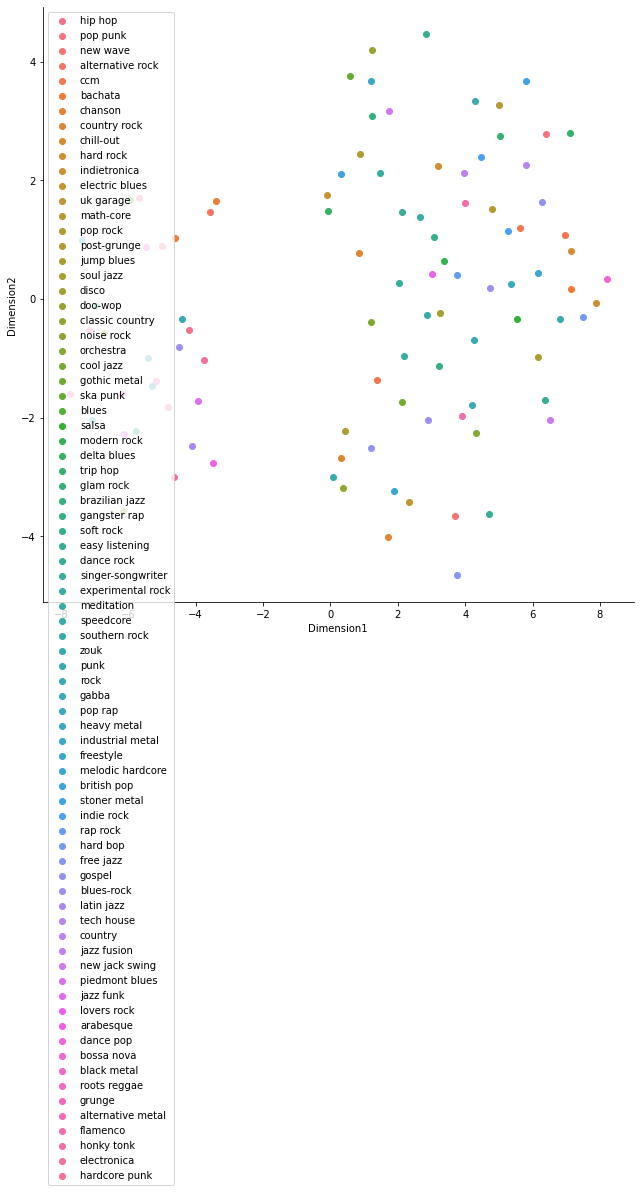

In [ ]:
sns.FacetGrid(tsne_df, hue="Label",height=9).map(plt.scatter, "Dimension1", "Dimension2")
plt.legend()